In [7]:
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
import random
%matplotlib inline

In [8]:
with open('names.txt', 'r') as f:
    words = f.read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [9]:
len(words)

32033

In [12]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(len(itos))

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [11]:
# building the dataset
block_size = 3 # context length: how many characters do we take to predict the next

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(13)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


In [55]:
# mlp
n_embd =10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.1
b1 = torch.randn(n_hidden, generator=g) * 0.1
W2 = torch.randn((n_hidden, vocab_size), generator=g)* 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.1

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [56]:
# optimization
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb  = C[Xb]
    embcat = emb.view(emb.shape[0], -1) # concatenate the embeddings
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    lossi.append(loss.log10().item())
    if i % 10_000 == 0:
        print(f"{i:7d}/{max_steps}: {loss.item():.4f} ({loss.log10().item():.4f})")
    
    # break

      0/200000: 3.2595 (0.5132)


  10000/200000: 2.1745 (0.3374)
  20000/200000: 1.7837 (0.2513)
  30000/200000: 2.4056 (0.3812)
  40000/200000: 1.9278 (0.2851)
  50000/200000: 2.8323 (0.4521)
  60000/200000: 2.4586 (0.3907)
  70000/200000: 2.3440 (0.3700)
  80000/200000: 2.1520 (0.3328)
  90000/200000: 2.1444 (0.3313)
 100000/200000: 2.3640 (0.3736)
 110000/200000: 1.9909 (0.2991)
 120000/200000: 2.3896 (0.3783)
 130000/200000: 1.9979 (0.3006)
 140000/200000: 2.0348 (0.3085)
 150000/200000: 2.1404 (0.3305)
 160000/200000: 2.2015 (0.3427)
 170000/200000: 1.9470 (0.2894)
 180000/200000: 1.9581 (0.2918)
 190000/200000: 2.3872 (0.3779)


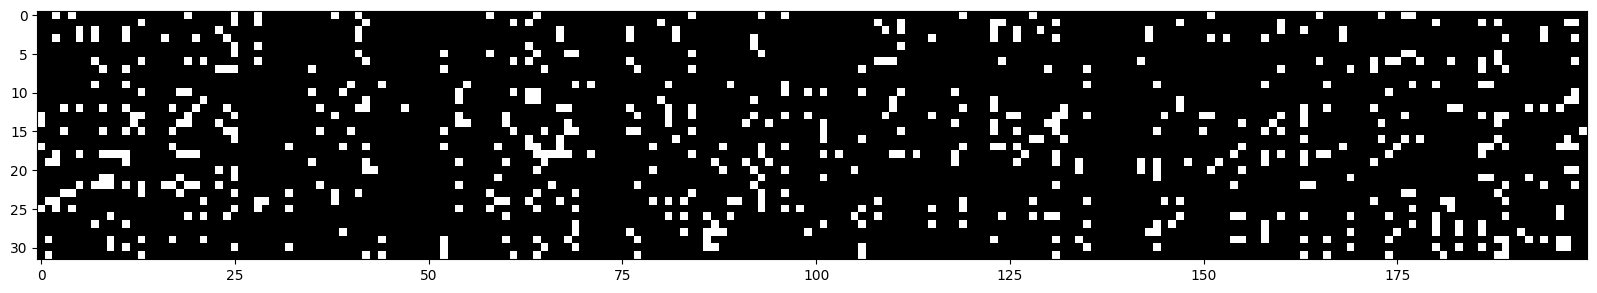

In [57]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.999, cmap='gray', interpolation='nearest')
plt.show()

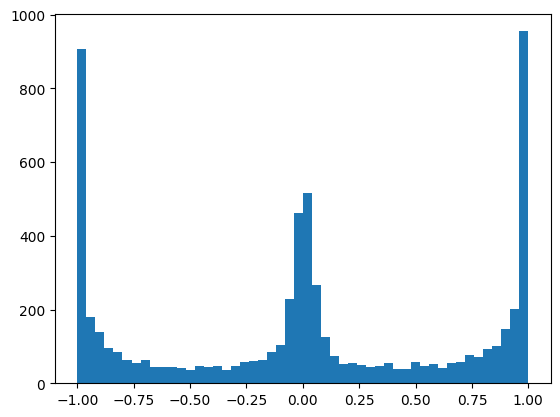

In [58]:
plt.hist(h.view(-1).tolist(), 50)
plt.show()

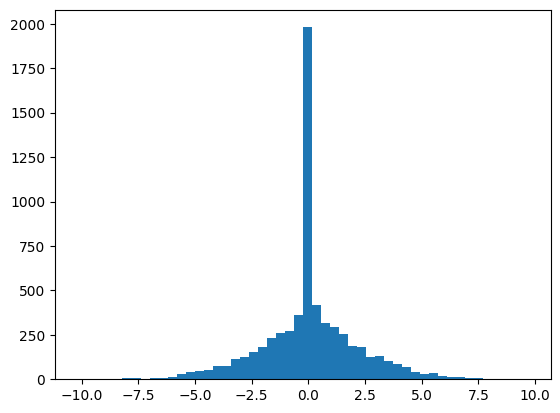

In [59]:
plt.hist(hpreact.view(-1).tolist(), 50)
plt.show()

In [60]:
-torch.tensor(1/27).log()

tensor(3.2958)

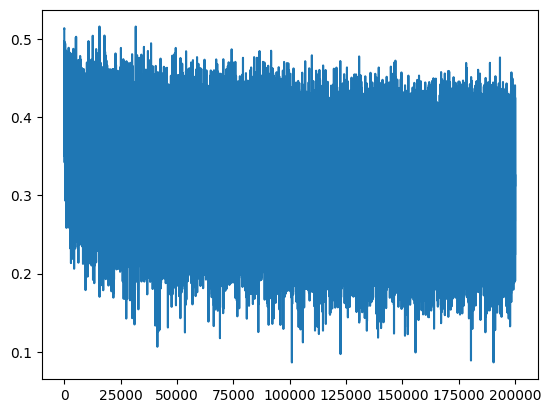

In [61]:
plt.plot(lossi)
plt.show()

In [62]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(f"{split} loss: {loss.item():.4f}")

split_loss('train')
split_loss('val')

train loss: 2.0572
val loss: 2.1231


### result of scalling down W2 & b2
- train loss: 2.0677
- val loss: 2.1420

### result of scalling down also W1 & b1
- train loss: 2.0572
- val loss: 2.1231

In [18]:
# Sample from the model

g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb  = C[torch.tensor([context])]
        h = torch.tanh(emb.view(-1, n_embd * block_size) @ W1 + b1)
        logits = h @ W2 + b2
        counts = logits.exp()
        prob = counts/counts.sum(1, keepdims = True)
        ix = torch.multinomial(prob, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join([itos[i] for i in out]))
        

cerze.
corlynn.
ila.
kayda.
kolimitta.
noluwan.
katar.
samiyah.
javer.
gotti.
moli.
daniu.
kenteda.
kaley.
maside.
enkaviyah.
fols.
milliven.
tahlan.
kashra.
